In [1]:
# import splitfolders # or import splitfolders
# input_folder = "/kaggle/input/arabic-letters-numbers-ocr/Dataset"
# path="/kaggle/input/arabic-letters-numbers-ocr/Dataset"
# output = "/kaggle/input/split/" #where you want the split datasets saved. one will be created if it does not exist or none is set

# # splitfolders.ratio(input_folder, output=output, seed=42, ratio=(.8, .1, .1)) # ratio of split are in order of train/val/test. You can change to whatever you want. For train/val sets only, you could do .75, .25 for example.
# splitfolders.ratio(path,seed=1337, output="ImgSplitted", ratio=(.8, .1, .1))


In [2]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import os
import glob as gb
import cv2
# from keras.preprocessing.image import ImageDataGenerator
# from tensorflow.keras.preprocessing import image_dataset_from_directory  
# from tensorflow.keras.preprocessing import image
import keras
import tensorflow
from tensorflow.keras.layers import Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score #,confusion_matrix,classification_report,,recall_score,precision_score,f1_score

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
# train_path='/kaggle/input/arabic-letters-numbers-ocr/Dataset/'
# # /kaggle/input/arabic-letters-numbers-ocr/Dataset/ا/0.png
# #/kaggle/input/arabic-letters-numbers-ocr/Dataset/ا
# for folder in os.listdir(train_path ):
#     images=gb.glob(pathname=str(train_path  + folder +'/*.png'))
#     print(f'for training data, found {len(images)} in folder {folder}')

set a dictionary for labeling the letters

In [4]:
# num=0
# for folder in os.listdir(train_path ):
#     print(f"'{folder}':{num}")
#     num+=1

In [5]:
code={'س':0,'و':1,'ظ':2,'ط':3,'غ':4,'ف':5,'ا':6,'٣':7,'ض':8,'ث':9,'ذ':10,'٩':11,'ق':12,'١':13,'ش':14,'٤':15,'ص':16,'ب':17,'٥':18,'ت':19,'لا':20,'٠':21,'ي':22,'ج':23,'ح':24,'خ':25,'٧':26,'ز':27,'٨':28,'ه':29,'د':30,'٢':31,'ك':32,'م':33,'ر':34,'ل':35,'ن':36,'٦':37,'ع':38 }

def getname(n):
    for k,v in code.items():
        if v==n:
            return k

In [6]:
code.get('ل')

35

In [7]:
getname(5)

'ف'

# loading data

In [8]:
data=[]
data_y=[]

In [9]:
train_path='/kaggle/input/arabic-letters-numbers-ocr/Dataset/'
for folder in os.listdir(train_path):
    images=gb.glob(pathname=str(train_path  + folder +'/*.png'))
    print(folder)
    for img in images:
        img=cv2.imread(img,0)
        img=cv2.resize(img,(100,100))
        data.append(img)
        data_y.append(code[folder])

س
و
ظ
ط
غ
ف
ا
٣
ض
ث
ذ
٩
ق
١
ش
٤
ص
ب
٥
ت
لا
٠
ي
ج
ح
خ
٧
ز
٨
ه
د
٢
ك
م
ر
ل
ن
٦
ع


In [10]:
# #get less images just for checking with BREAKING early 
# data=[]
# data_y=[]
# count=0
# for folder in os.listdir(train_path):
#     if count==2:
#         break
#     images=gb.glob(pathname=str(train_path  + folder +'/*.png'))
#     print(count)
#     count+=1
#     for img in images:
#         img=cv2.imread(img,0)#cv2.IMREAD_GRAYSCALE)
#         img=cv2.resize(img,(100,100))
#         data.append(img)
#         data_y.append(code[folder])

plot sample of data

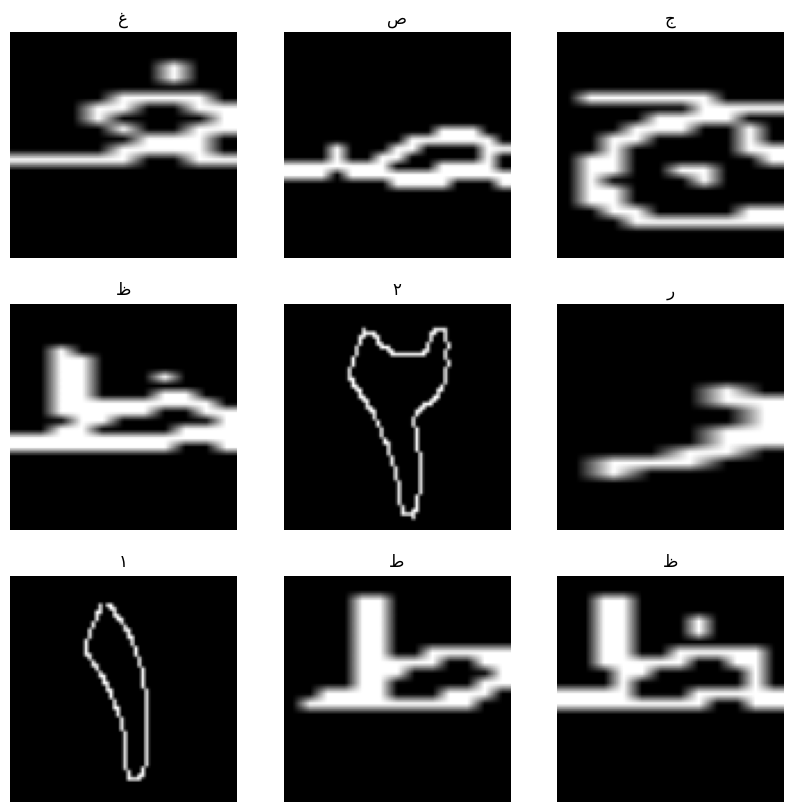

In [11]:
plt.figure(figsize=(10,10))
for i,v in enumerate(np.random.randint(0,len(data),9)):
    plt.subplot(3,3,i+1)
    plt.imshow(data[v],cmap="gray")
    plt.title(getname(data_y[v]))
    plt.axis('off')

In [12]:
from collections import Counter

counter = Counter(data_y)

for k,v in sorted(counter.items()):
    print(k,":",v)

0 : 2481
1 : 2481
2 : 2481
3 : 2481
4 : 2481
5 : 2481
6 : 2481
7 : 2480
8 : 2481
9 : 2481
10 : 2481
11 : 2480
12 : 2481
13 : 2480
14 : 2481
15 : 2480
16 : 2481
17 : 2481
18 : 2480
19 : 2481
20 : 2481
21 : 2480
22 : 2481
23 : 2481
24 : 2481
25 : 2481
26 : 2480
27 : 2481
28 : 2480
29 : 2481
30 : 2481
31 : 2480
32 : 2481
33 : 2481
34 : 2481
35 : 2481
36 : 2481
37 : 2480
38 : 2481


**i miss nirmalization**

In [13]:
data = np.array(data)
data_y = np.array(data_y)

In [14]:
data = data / 255.0

In [15]:
data = np.expand_dims(data,axis=-1)

In [16]:
print(data.shape)
print(data_y.shape)

(96749, 100, 100, 1)
(96749,)


In [17]:
#data,data_y = shuffle(data,data_y,random_state=42)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    data,
    data_y,
    test_size=0.2,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    random_state=42
)

In [19]:
model = keras.models.Sequential([

    keras.layers.Conv2D(
        200,
        (3,3),
        activation='relu',
        input_shape=(100,100,1)
    ),

    keras.layers.Conv2D(
        150,
        (3,3),
        activation='relu'
    ),

    keras.layers.MaxPool2D(4,4),

    keras.layers.Conv2D(
        120,
        (3,3),
        activation='relu'
    ),

    keras.layers.Conv2D(
        80,
        (3,3),
        activation='relu'
    ),

    keras.layers.Conv2D(
        50,
        (3,3),
        activation='relu'
    ),

    keras.layers.MaxPool2D(4,4),

    keras.layers.Flatten(),

    keras.layers.Dense(
        120,
        activation='relu'
    ),

    keras.layers.Dense(
        100,
        activation='relu'
    ),

    keras.layers.Dense(
        50,
        activation='relu'
    ),

    keras.layers.Dense(
        39,
        activation='softmax'
    )

])

In [20]:
model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']

)

In [21]:
from keras.callbacks import EarlyStopping

es = EarlyStopping(

    monitor='val_loss',

    mode='min',

    patience=3,

    restore_best_weights=True

)

In [22]:
history = model.fit(

    X_train,
    y_train,

    validation_data=(X_val,y_val),

    epochs=20,

    batch_size=64,

    callbacks=[es]

)

Epoch 1/20
908/908 [==============================] - 106s 104ms/step - loss: 0.2869 - accuracy: 0.9206 - val_loss: 0.3792 - val_accuracy: 0.8920
Epoch 2/20
908/908 [==============================] - 91s 101ms/step - loss: 0.1177 - accuracy: 0.9697 - val_loss: 0.0696 - val_accuracy: 0.9811
Epoch 3/20
908/908 [==============================] - 91s 101ms/step - loss: 0.1759 - accuracy: 0.9715 - val_loss: 0.0810 - val_accuracy: 0.9858
Epoch 4/20
908/908 [==============================] - 91s 101ms/step - loss: 0.9427 - accuracy: 0.9580 - val_loss: 0.1915 - val_accuracy: 0.9533
Epoch 5/20
908/908 [==============================] - 91s 101ms/step - loss: 1.2750 - accuracy: 0.7437 - val_loss: 0.4623 - val_accuracy: 0.8609


In [23]:
loss,acc = model.evaluate(X_test,y_test)

print("Loss :",loss)
print("Accuracy :",acc)

605/605 [==============================] - 9s 14ms/step - loss: 1.5184 - accuracy: 0.6471
Loss : 1.5183666944503784
Accuracy : 0.6471318006515503


yolo

In [24]:
import os

os.makedirs("yolo_dataset/images/train", exist_ok=True)
os.makedirs("yolo_dataset/images/val", exist_ok=True)

os.makedirs("yolo_dataset/labels/train", exist_ok=True)
os.makedirs("yolo_dataset/labels/val", exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


In [25]:
import os
import cv2
import glob as gb
import shutil
import random
from tqdm import tqdm


# نفس الـ mapping بتاع الـ CNN
classes = code


src_path = "/kaggle/input/arabic-letters-numbers-ocr/Dataset/"


images_out = "yolo_dataset/images/train"
labels_out = "yolo_dataset/labels/train"


for folder in os.listdir(src_path):

    class_id = classes[folder]

    images = gb.glob(src_path + folder + "/*.png")

    for img_path in tqdm(images, desc=folder):

        img = cv2.imread(img_path, 0)

        h, w = img.shape


        # Threshold
        _, thresh = cv2.threshold(
            img,
            0,
            255,
            cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
        )


        contours, _ = cv2.findContours(
            thresh,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )


        if len(contours) == 0:
            continue


        # أكبر contour (الحرف)
        c = max(contours, key=cv2.contourArea)


        x, y, bw, bh = cv2.boundingRect(c)


        # تحويل YOLO format
        x_center = (x + bw/2) / w
        y_center = (y + bh/2) / h

        width = bw / w
        height = bh / h


        # حفظ الصورة
        img_name = os.path.basename(img_path)

        new_img_path = os.path.join(
            images_out,
            img_name
        )

        shutil.copy(
            img_path,
            new_img_path
        )


        # حفظ label
        label_name = img_name.replace(".png",".txt")

        label_path = os.path.join(
            labels_out,
            label_name
        )


        with open(label_path,"w") as f:
            f.write(
                f"{class_id} {x_center} {y_center} {width} {height}"
            )


print("Conversion finished")

ع: 100%|██████████| 2481/2481 [00:04<00:00, 562.26it/s]

Conversion finished


In [26]:
print(len(os.listdir("yolo_dataset/images/train")))
print(len(os.listdir("yolo_dataset/labels/train")))

4647
4647


In [27]:
id="8l2k4v"
import random
import shutil
import os


images_train = "yolo_dataset/images/train"
labels_train = "yolo_dataset/labels/train"

images_val = "yolo_dataset/images/val"
labels_val = "yolo_dataset/labels/val"


files = os.listdir(images_train)

random.seed(42)

val_files = random.sample(
    files,
    int(len(files)*0.2)
)


for file in val_files:

    # image
    shutil.move(
        os.path.join(images_train,file),
        os.path.join(images_val,file)
    )


    # label
    label = file.replace(".png",".txt")

    shutil.move(
        os.path.join(labels_train,label),
        os.path.join(labels_val,label)
    )


print("Train images:",len(os.listdir(images_train)))
print("Val images:",len(os.listdir(images_val)))

Train images: 3718
Val images: 929


In [28]:
from pathlib import Path

yaml_content = """
path: /kaggle/working/yolo_dataset

train: images/train
val: images/val

nc: 39

names:
  - ا
  - ب
  - ت
  - ث
  - ج
  - ح
  - خ
  - د
  - ذ
  - ر
  - ز
  - س
  - ش
  - ص
  - ض
  - ط
  - ظ
  - ع
  - غ
  - ف
  - ق
  - ك
  - ل
  - م
  - ن
  - ه
  - و
  - ي
  - لا
  - ٠
  - ١
  - ٢
  - ٣
  - ٤
  - ٥
  - ٦
  - ٧
  - ٨
  - ٩
"""


with open("/kaggle/working/data.yaml","w",encoding="utf-8") as f:
    f.write(yaml_content)


print("yaml created")

yaml created


In [29]:
print(open("/kaggle/working/data.yaml",encoding="utf-8").read())


path: /kaggle/working/yolo_dataset

train: images/train
val: images/val

nc: 39

names:
  - ا
  - ب
  - ت
  - ث
  - ج
  - ح
  - خ
  - د
  - ذ
  - ر
  - ز
  - س
  - ش
  - ص
  - ض
  - ط
  - ظ
  - ع
  - غ
  - ف
  - ق
  - ك
  - ل
  - م
  - ن
  - ه
  - و
  - ي
  - لا
  - ٠
  - ١
  - ٢
  - ٣
  - ٤
  - ٥
  - ٦
  - ٧
  - ٨
  - ٩



In [30]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 837.6/837.6 kB 28.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 MB 26.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-ml-py
    Found existing installation: nvidia-ml-py 11.495.46
    Uninstalling nvidia-ml-py-11.495.46:
      Successfully uninstalled nvidia-ml-py-11.495.46
  Attempting uninstall: polars
    Found existing installation: polars 0.19.2
    Uninstalling polars-0.19.2:
      Successfully uninstalled polars-0.19.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gpustat 1.0.0 requires nvidia-ml-py<=11.495.46,>=11.450.129, but you have nvidia-ml-py 13.610.43 which is incompatible.


In [31]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [32]:
model_yolo = YOLO("yolov8n.pt")

In [33]:
results = model_yolo.train(
    data="/kaggle/working/data.yaml",
    epochs=50,
    imgsz=100,
    batch=32
)

Ultralytics 8.4.90 🚀 Python-3.10.12 torch-2.0.0 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=100, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10


image 1/1 /kaggle/input/datasets/fadywadeewilliam/egymomword/Screenshot (838).png: 96x128 (no detections), 49.5ms
Speed: 0.5ms preprocess, 49.5ms inference, 0.6ms postprocess per image at shape (1, 3, 96, 128)


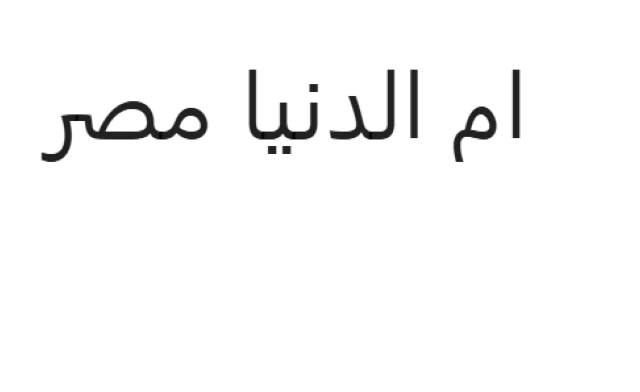

In [34]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2


# تحميل أفضل وزن
yolo = YOLO(
    "/kaggle/working/runs/detect/train/weights/best.pt"
)


img_path = "/kaggle/input/datasets/fadywadeewilliam/egymomword/Screenshot (838).png"


results = yolo.predict(
    img_path,
    conf=0.25
)


# عرض النتيجة
annotated = results[0].plot()

plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off");

In [35]:
boxes = results[0].boxes.xyxy.cpu().numpy()

print("Number of characters detected:", len(boxes))
print(boxes)

Number of characters detected: 0
[]


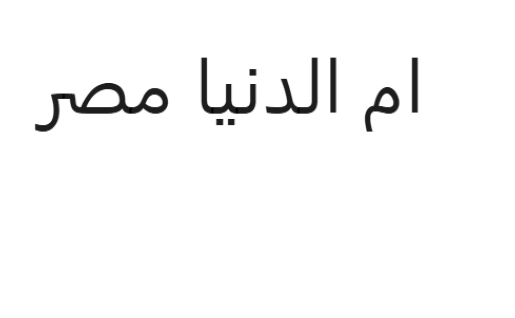

In [36]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/kaggle/input/datasets/fadywadeewilliam/egymomword/Screenshot (838).png")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap="gray")
plt.axis("off");

In [37]:
_, thresh = cv2.threshold(
    gray,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

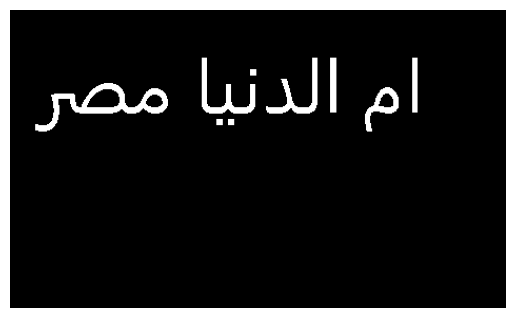

In [38]:
plt.imshow(thresh, cmap="gray")
plt.axis("off");

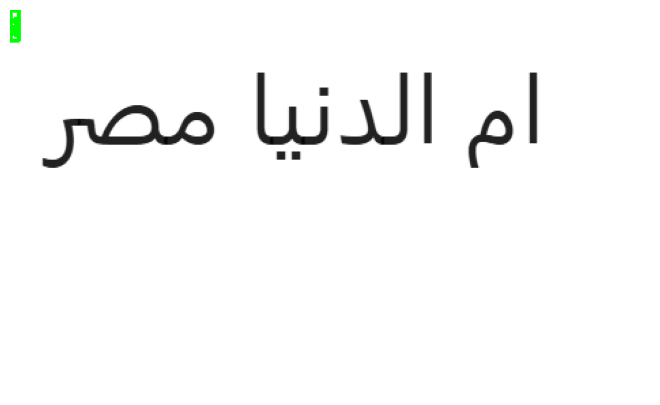

In [39]:
import cv2
import matplotlib.pyplot as plt

img_copy = img.copy()

for c in contours:
    x, y, w, h = cv2.boundingRect(c)
    
    cv2.rectangle(
        img_copy,
        (x, y),
        (x+w, y+h),
        (0,255,0),
        2
    )

plt.figure(figsize=(10,5))
plt.imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))
plt.axis("off");

Number of boxes: 1


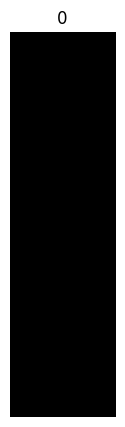

In [40]:
import cv2
import matplotlib.pyplot as plt

# نسخة من الصورة للرسم عليها
img_copy = img.copy()

# استخراج الـ bounding boxes
boxes = []

for c in contours:
    x, y, w, h = cv2.boundingRect(c)

    # تجاهل الـ noise والأجزاء الصغيرة جدًا
    if w > 5 and h > 5:
        boxes.append((x, y, w, h))

print("Number of boxes:", len(boxes))


# ترتيب من اليمين لليسار (العربي)
boxes = sorted(boxes, key=lambda b: b[0], reverse=True)


# قص كل حرف
characters = []

for x, y, w, h in boxes:
    char = gray[y:y+h, x:x+w]
    characters.append(char)

    
# عرض الحروف بعد التقسيم
plt.figure(figsize=(15,5))

for i, char in enumerate(characters):
    plt.subplot(1, len(characters), i+1)
    plt.imshow(char, cmap="gray")
    plt.title(i)
    plt.axis("off")

plt.show()

In [41]:
import numpy as np
import cv2

processed_chars = []

for char in characters:

    # Resize لنفس حجم التدريب
    char = cv2.resize(char, (100,100))

    # Normalize
    char = char / 255.0

    # إضافة channel
    char = np.expand_dims(char, axis=-1)

    processed_chars.append(char)


# تحويل إلى numpy array
processed_chars = np.array(processed_chars)

print(processed_chars.shape)

(1, 100, 100, 1)


In [42]:
predictions = model.predict(processed_chars)

1/1 [==============================] - 0s 137ms/step


In [43]:
predicted_classes = np.argmax(predictions, axis=1)

In [44]:
# عكس الـ dictionary
decode = {v:k for k,v in code.items()}

print(decode)

{0: 'س', 1: 'و', 2: 'ظ', 3: 'ط', 4: 'غ', 5: 'ف', 6: 'ا', 7: '٣', 8: 'ض', 9: 'ث', 10: 'ذ', 11: '٩', 12: 'ق', 13: '١', 14: 'ش', 15: '٤', 16: 'ص', 17: 'ب', 18: '٥', 19: 'ت', 20: 'لا', 21: '٠', 22: 'ي', 23: 'ج', 24: 'ح', 25: 'خ', 26: '٧', 27: 'ز', 28: '٨', 29: 'ه', 30: 'د', 31: '٢', 32: 'ك', 33: 'م', 34: 'ر', 35: 'ل', 36: 'ن', 37: '٦', 38: 'ع'}


In [45]:
predicted_chars = []

for p in predicted_classes:
    predicted_chars.append(decode[p])

print(predicted_chars)

['ل']


In [46]:
text = ''.join(predicted_chars)

print(text)

ل


# model 2

# load model and try

# show results

**مصر**